In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(
    r"C:\Users\KALLOL\OneDrive\Desktop\Machine Learning\SMS_Spam_Detector\spam.csv",
    encoding="latin-1"
)

In [3]:
df.sample(5)
df.shape

(5572, 5)

1.Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [6]:
# renaming the columns
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [7]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [8]:
df['target']=encoder.fit_transform(df['target'])

In [9]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
df=df.drop_duplicates(keep='first')
df.shape

(5169, 2)

2.EDA

In [12]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

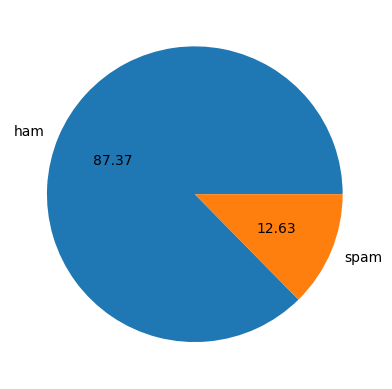

In [13]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [14]:
!pip install nltk

In [15]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


# Data imbalanced

In [16]:
import nltk

In [17]:
#No. of chacerters
df['num_char']=df['text'].apply(len)
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KALLOL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KALLOL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
%pip install wordcloud



Note: you may need to restart the kernel to use updated packages.


In [20]:
# num of words
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [21]:
df['num_sent']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [22]:
df[['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [23]:
#ham
df[df['target']==0][['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
#spam
df[df['target']==1][['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [25]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

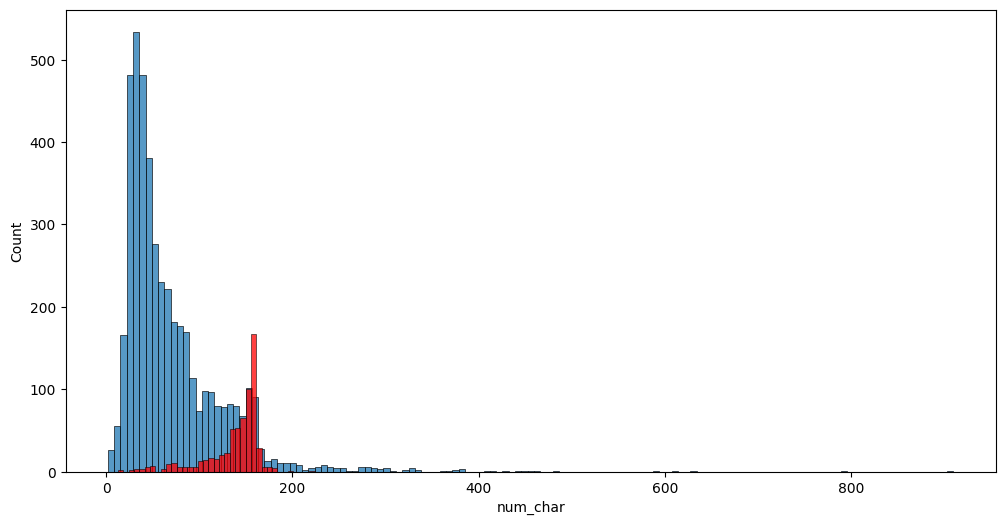

In [26]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_char'])
sns.histplot(df[df['target']==1]['num_char'],color='red')

<Axes: >

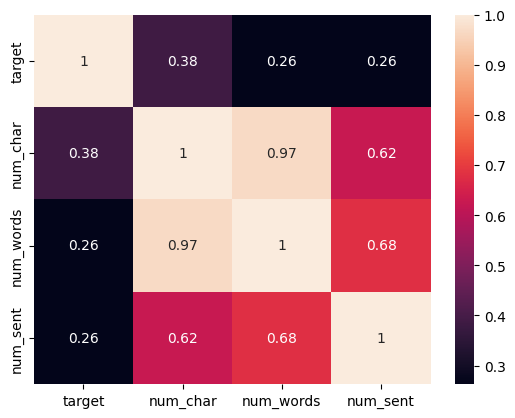

In [27]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

3.Data Preprocessing

In [28]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps=PorterStemmer()

def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)


In [29]:
df['transformed_text']=df['text'].apply(transform_text)

In [30]:
df.head()

,target,text,num_char,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [31]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [32]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

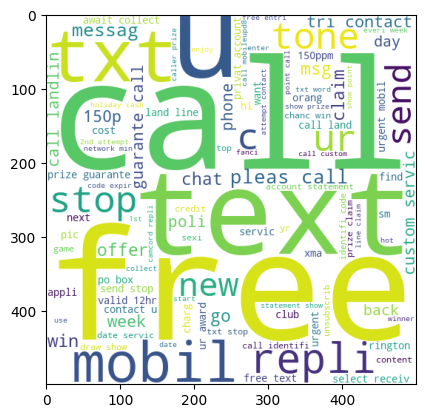

In [33]:
plt.imshow(spam_wc)

In [34]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

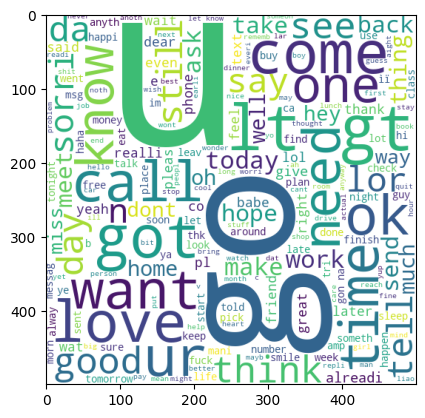

In [35]:
plt.imshow(spam_wc)

In [36]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

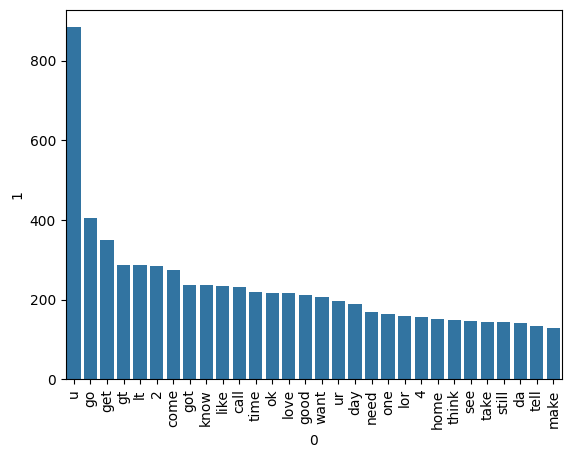

In [37]:
from collections import Counter
top_words = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=top_words[0], y=top_words[1])

plt.xticks(rotation='vertical')
plt.show()

In [38]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

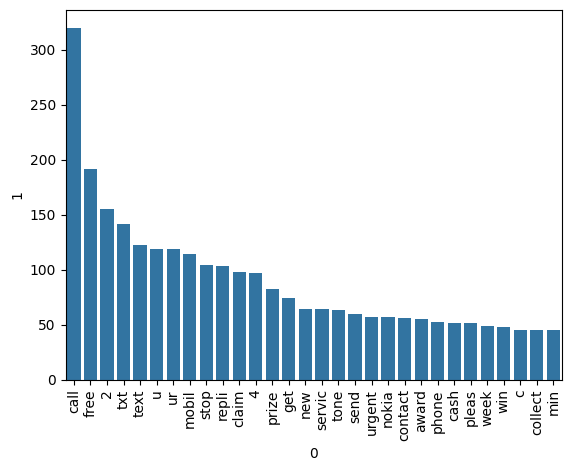

In [39]:
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=top_words[0], y=top_words[1])

plt.xticks(rotation='vertical')
plt.show()

4.Model Building

In [40]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
print(X.shape)

(5169, 3000)


In [41]:
y=df['target'].values

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB


In [44]:
gnb=GaussianNB()
bnb=BernoulliNB()
mnb=MultinomialNB()

In [45]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8626692456479691
[[771 118]
 [ 24 121]]
0.5062761506276151


In [46]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9729206963249516
[[888   1]
 [ 27 118]]
0.9915966386554622


In [47]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9729206963249516
[[884   5]
 [ 23 122]]
0.9606299212598425


In [48]:
#tfidf__mnb

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [50]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [51]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [52]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [53]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9477611940298507
For  KN
Accuracy -  0.9042553191489362
Precision -  1.0
For  NB
Accuracy -  0.9729206963249516
Precision -  0.9915966386554622
For  DT
Accuracy -  0.9313346228239845
Precision -  0.8135593220338984
For  LR
Accuracy -  0.9468085106382979
Precision -  0.8629032258064516
For  RF
Accuracy -  0.971953578336557
Precision -  0.9915254237288136
For  AdaBoost
Accuracy -  0.913926499032882
Precision -  0.7916666666666666
For  BgC
Accuracy -  0.960348162475822
Precision -  0.8768115942028986
For  ETC
Accuracy -  0.9796905222437138
Precision -  1.0
For  GBDT
Accuracy -  0.9497098646034816
Precision -  0.9514563106796117
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9375


In [54]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [55]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.904255,1.000000
8,ETC,0.979691,1.000000
2,NB,0.972921,0.991597
5,RF,0.971954,0.991525
9,GBDT,0.949710,0.951456
0,SVC,0.975822,0.947761
10,xgb,0.968085,0.937500
7,BgC,0.960348,0.876812
4,LR,0.946809,0.862903
3,DT,0.931335,0.813559


In [56]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [57]:

performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.904255
1,ETC,Accuracy,0.979691
2,NB,Accuracy,0.972921
3,RF,Accuracy,0.971954
4,GBDT,Accuracy,0.949710
5,SVC,Accuracy,0.975822
6,xgb,Accuracy,0.968085
7,BgC,Accuracy,0.960348
8,LR,Accuracy,0.946809
9,DT,Accuracy,0.931335


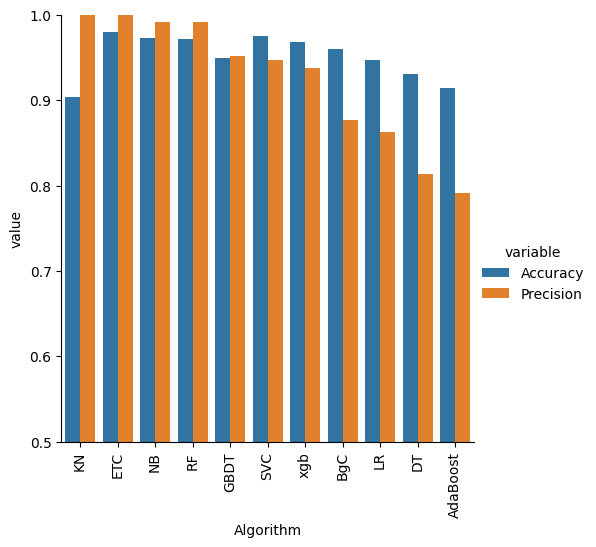

In [58]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [59]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [60]:
temp_df

,Algorithm,Accuracy_max_ft_3000,Precision_max_ft_3000
1,KN,0.904255,1.000000
8,ETC,0.979691,1.000000
2,NB,0.972921,0.991597
5,RF,0.971954,0.991525
9,GBDT,0.949710,0.951456
0,SVC,0.975822,0.947761
10,xgb,0.968085,0.937500
7,BgC,0.960348,0.876812
4,LR,0.946809,0.862903
3,DT,0.931335,0.813559


In [61]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [62]:
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [63]:
import pickle

model = pickle.load(open('model.pkl','rb'))
vectorizer = pickle.load(open('vectorizer.pkl','rb'))

msg = "Your bank account has been suspended. Click here to verify."

transformed = transform_text(msg)

vector = vectorizer.transform([transformed])

print(model.predict(vector))

[0]


In [64]:
from sklearn.metrics import accuracy_score, precision_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Accuracy: 0.9729206963249516
Precision: 0.9915966386554622


In [65]:
from sklearn.metrics import recall_score, f1_score

y_pred = model.predict(X_test)

print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Recall: 0.8137931034482758
F1: 0.8939393939393939


In [66]:
msg = "URGENT: Unusual login detected on your HDFC account. Please verify your identity immediately to prevent account suspension: suspicious link"

transformed = transform_text(msg)

vector = tfidf.transform([transformed])   # or vectorizer.transform([transformed])

prediction = model.predict(vector)[0]

confidence = round(
    max(model.predict_proba(vector)[0]) * 100,
    2
)

print("Message:")
print(msg)
print()

print("Prediction:", "Spam" if prediction == 1 else "Ham")
print("Confidence:", confidence, "%")

Message:
URGENT: Unusual login detected on your HDFC account. Please verify your identity immediately to prevent account suspension: suspicious link

Prediction: Spam
Confidence: 68.65 %


In [67]:
msg ="Congratulations! You've been randomly selected to win a ₹10,000 Amazon Gift Card! Claim your prize now:"

transformed = transform_text(msg)

vector = tfidf.transform([transformed])   # or vectorizer.transform([transformed])

prediction = model.predict(vector)[0]

confidence = round(
    max(model.predict_proba(vector)[0]) * 100,
    2
)

print("Message:")
print(msg)
print()

print("Prediction:", "Spam" if prediction == 1 else "Ham")
print("Confidence:", confidence, "%")

Message:
Congratulations! You've been randomly selected to win a ₹10,000 Amazon Gift Card! Claim your prize now:

Prediction: Spam
Confidence: 96.58 %


In [68]:
msg = "Hi, it's your manager. I need you to purchase ₹5000 in gift cards for a client right now. Send me the codes."


transformed = transform_text(msg)

vector = tfidf.transform([transformed])   # or vectorizer.transform([transformed])

prediction = model.predict(vector)[0]

confidence = round(
    max(model.predict_proba(vector)[0]) * 100,
    2
)

print("Message:")
print(msg)
print()

print("Prediction:", "Spam" if prediction == 1 else "Ham")
print("Confidence:", confidence, "%")

Message:
Hi, it's your manager. I need you to purchase ₹5000 in gift cards for a client right now. Send me the codes.

Prediction: Ham
Confidence: 89.48 %


In [69]:
msg =  "Hi, is this Rahul? Sorry, wrong number—but you seem nice! What do you do for work?"


transformed = transform_text(msg)

vector = tfidf.transform([transformed])   # or vectorizer.transform([transformed])

prediction = model.predict(vector)[0]

confidence = round(
    max(model.predict_proba(vector)[0]) * 100,
    2
)

print("Message:")
print(msg)
print()

print("Prediction:", "Spam" if prediction == 1 else "Ham")
print("Confidence:", confidence, "%")

Message:
Hi, is this Rahul? Sorry, wrong number—but you seem nice! What do you do for work?

Prediction: Ham
Confidence: 99.1 %
